# Evaluation: Efficacy of Initial Root Bootstrapping

**Objective:** Exemplary quantification of the resource savings achieved through root bootstrapping within the defined experimental setup. 

**Data Basis:** 
* 50 generated initial multi-hop questions (Turn 0).
* Source documents: Chunks from the `V_eval` dataset.
* Persona: "Your questions are very short and precise"
* Tracked metrics per component (Context Discoverer (CD), Conversation Generator (CG), Conversation Validator(CE)): Execution time (latency), input/output tokens, and the number of CV rejections (retries).

The anlyses in this script help to make cost savings with initial roots bootstrapping comparable to the subsequent tree caching analyses, which operate on the exact same deterministic setup. Standalone absolute numbers are not generaliseable as they were executed on the a specific experimental setup (prompt, test setup). 

In [19]:
# plots generated by Gemini-3.1-Pro with careful instruction and review of Daniel Hillebrand

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# ============ GLOBAL STYLING ============
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

C_PRIMARY = '#1a5276'
C_SECONDARY = '#c0392b'
C_TERTIARY = '#f39c12'
C_QUATERNARY = '#27ae60'
C_ACCENT = '#8e44ad'
C_DARK = '#2c3e50'

BAR_COLORS = [C_PRIMARY, C_SECONDARY, C_TERTIARY, C_QUATERNARY]
TIME_COLORS = [C_PRIMARY, C_SECONDARY, C_TERTIARY]
CMAP_MAIN = sns.light_palette(C_PRIMARY, as_cmap=True)
CMAP_DIV = sns.diverging_palette(220, 10, s=80, l=50, as_cmap=True)

def get_turn_palette(n):
    base = [C_PRIMARY, C_QUATERNARY, C_TERTIARY, C_SECONDARY, C_ACCENT, C_DARK]
    return sns.color_palette(base[:n], n) if n <= len(base) else sns.color_palette(base, n)

# ============ DATA PREPARATION ============
# Load the generated JSONL metrics
DATA_PATH = "root_caching_metrics.jsonl"
data = []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line.strip()))

df = pd.DataFrame(data)

# Calculate total tokens (Input + Output) per component
df['CD Tokens'] = df['cd_tokens_in'] + df['cd_tokens_out']
df['CG Tokens'] = df['cg_tokens_in'] + df['cg_tokens_out']
df['CV Tokens'] = df['cv_tokens_in'] + df['cv_tokens_out']
df['Total Tokens'] = df['CD Tokens'] + df['CG Tokens'] + df['CV Tokens']
df['Total Time'] = df['cd_latency_sec'] + df['cg_latency_sec'] + df['cv_latency_sec']

df.head()

,conversation_id,cd_latency_sec,cd_tokens_in,cd_tokens_out,cg_latency_sec,cg_tokens_in,cg_tokens_out,cv_latency_sec,cv_tokens_in,cv_tokens_out,cv_rejections,CD Tokens,CG Tokens,CV Tokens,Total Tokens,Total Time
0,1,3.15,1216,63,0.99,1059,193,6.65,783,598,0,1279,1252,1381,3912,10.79
1,2,1.72,685,53,2.50,2838,425,23.08,1879,1921,1,738,3263,3800,7801,27.30
2,3,1.98,631,50,1.26,1144,198,17.18,891,790,0,681,1342,1681,3704,20.42
3,4,1.74,627,54,1.13,1132,244,9.45,915,918,0,681,1376,1833,3890,12.32
4,5,1.52,741,44,1.48,1248,263,10.06,1033,1238,0,785,1511,2271,4567,13.06


## key statistic: token / latency breakdown (mean, sd, ...)

In [27]:
token_stats = df[['CD Tokens', 'CG Tokens', 'CV Tokens', 'Total Tokens', 'cv_tokens_in', 'cv_tokens_out', 'cd_tokens_in', 'cd_tokens_out', 'cg_tokens_in', 'cg_tokens_out']].agg(['mean', 'median', 'std', 'max'])
token_stats.index = ['Mean', 'Median', 'Std Dev', 'Maximum']

display(token_stats.round(0))

# Print proportion of validation costs
mean_total = token_stats.loc['Mean', 'Total Tokens']
mean_cv = token_stats.loc['Mean', 'CV Tokens']
print(f"\nProportion of tokens consumed by the Validator (CV): {(mean_cv / mean_total) * 100:.1f}%")

,CD Tokens,CG Tokens,CV Tokens,Total Tokens,cv_tokens_in,cv_tokens_out,cd_tokens_in,cd_tokens_out,cg_tokens_in,cg_tokens_out
Mean,790.0,2054.0,2607.0,5451.0,1233.0,1374.0,740.0,50.0,1731.0,322.0
Median,690.0,1421.0,2003.0,4076.0,965.0,1078.0,636.0,47.0,1171.0,259.0
Std Dev,481.0,1155.0,1367.0,2757.0,517.0,902.0,468.0,15.0,1016.0,142.0
Maximum,3509.0,6302.0,7886.0,17697.0,2916.0,4970.0,3383.0,126.0,5493.0,809.0



Proportion of tokens consumed by the Validator (CV): 47.8%


In [28]:
time_stats = df[['cv_latency_sec', 'cg_latency_sec', 'cd_latency_sec', 'Total Time']].agg(['mean', 'median', 'std', 'max'])
time_stats.index = ['Mean', 'Median', 'Std Dev', 'Maximum']

display(time_stats.round(1))

# Print proportion of validation costs
mean_total = time_stats.loc['Mean', 'Total Time']
mean_cv = time_stats.loc['Mean', 'cv_latency_sec']
print(f"\nProportion of time consumed by the Validator (CV): {(mean_cv / mean_total) * 100:.1f}%")

,cv_latency_sec,cg_latency_sec,cd_latency_sec,Total Time
Mean,14.6,1.7,1.7,18.0
Median,10.6,1.3,1.6,13.6
Std Dev,9.7,0.8,0.5,10.6
Maximum,49.4,4.6,4.2,57.2



Proportion of time consumed by the Validator (CV): 81.0%


rejection rate: (from logs): 21 rejections bei (50+21) Generations = 0.295774648; 

per successful query, there are 21/50 = 0.42 regenerations

## distribution of token costs (boxplot)

/tmp/ipykernel_31678/1979100664.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


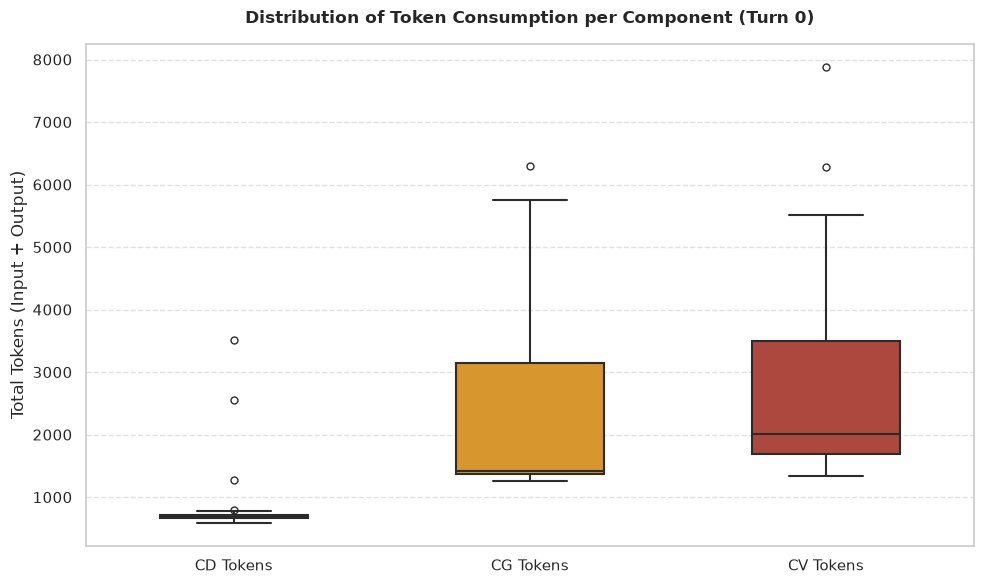

In [14]:
plt.figure(figsize=(10, 6))

df_melted = df.melt(
    id_vars=['conversation_id'], 
    value_vars=['CD Tokens', 'CG Tokens', 'CV Tokens'],
    var_name='Component', 
    value_name='Token Count' 
)


component_palette = {
    'CD Tokens': C_PRIMARY,
    'CG Tokens': C_TERTIARY,
    'CV Tokens': C_SECONDARY
}

sns.boxplot(
    data=df_melted, 
    x='Component', 
    y='Token Count',
    palette=component_palette,
    width=0.5,
    fliersize=5,
    linewidth=1.5
)

plt.title('Distribution of Token Consumption per Component (Turn 0)', pad=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Total Tokens (Input + Output)')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('token_consumption_distribution.pdf')
plt.show()

## latency + total cost plots

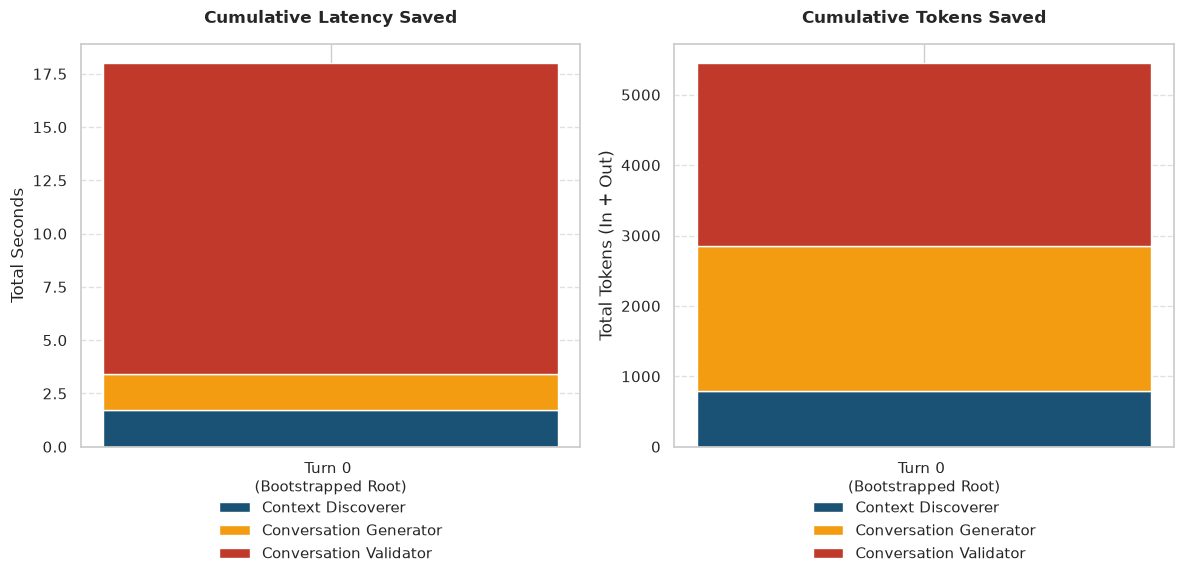

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Prepare aggregated means for stacking
cd_time = df['cd_latency_sec'].mean()
cg_time = df['cg_latency_sec'].mean()
cv_time = df['cv_latency_sec'].mean()

cd_tok = df['CD Tokens'].mean()
cg_tok = df['CG Tokens'].mean()
cv_tok = df['CV Tokens'].mean()

bar_label = ['Turn 0 \n(Bootstrapped Root)']

# --- Plot 1: Stacked Latency ---
axes[0].bar(bar_label, cd_time, color=C_PRIMARY, label='Context Discoverer', width=0.3, edgecolor='white')
axes[0].bar(bar_label, cg_time, bottom=cd_time, color=C_TERTIARY, label='Conversation Generator', width=0.3, edgecolor='white')
axes[0].bar(bar_label, cv_time, bottom=cd_time+cg_time, color=C_SECONDARY, label='Conversation Validator', width=0.3, edgecolor='white')

axes[0].set_title('Cumulative Latency Saved', pad=15, fontweight='bold')
axes[0].set_ylabel('Total Seconds')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
# Place legend outside the plot area
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1, frameon=False)

# --- Plot 2: Stacked Tokens ---
axes[1].bar(bar_label, cd_tok, color=C_PRIMARY, label='Context Discoverer', width=0.3, edgecolor='white')
axes[1].bar(bar_label, cg_tok, bottom=cd_tok, color=C_TERTIARY, label='Conversation Generator', width=0.3, edgecolor='white')
axes[1].bar(bar_label, cv_tok, bottom=cd_tok+cg_tok, color=C_SECONDARY, label='Conversation Validator', width=0.3, edgecolor='white')

axes[1].set_title('Cumulative Tokens Saved', pad=15, fontweight='bold')
axes[1].set_ylabel('Total Tokens (In + Out)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1, frameon=False)

plt.tight_layout()
plt.savefig('total_savings.pdf')
plt.show()